# TTLL10

Human TTLL10 ([UniProt Q6ZVT0](https://www.uniprot.org/uniprotkb/Q6ZVT0), 673 aa). There is no experimental structure of TTLL10 in the PDB, so this uses the AlphaFold model ([Jumper et al., 2021](https://www.nature.com/articles/s41586-021-03819-2)) from the AlphaFold Protein Structure Database ([Varadi et al., 2024](https://academic.oup.com/nar/article/52/D1/D368/7337620)). Residue numbers are UniProt numbers for the canonical isoform (1–673). Structure is rendered using 3Dmol.js ([Rego and Koes, 2015](https://academic.oup.com/bioinformatics/article/31/8/1322/213186)), loaded from the jsDelivr CDN, so internet access is needed for this.

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import seaborn as sns
import vscodenb
from geneinfo.structure import show_structure, alphamissense
import sys
from fisher import fisher_test
import warnings
warnings.simplefilter("ignore", UserWarning)

In [2]:
#>sp|Q6ZVT0|TTL10_HUMAN Tubulin tyrosine ligase-like protein 10 OS=Homo sapiens OX=9606 GN=TTLL10 PE=1 SV=2
seq = \
"MAGGRPHPEPLRRGPWRPGRGAQAAGGRGVRREGRGVAARVRGGASQDRPGRVRGRALSL" \
"PPAAGVGGPEEGPAQPPAEALSLSREARRRCLRLGLALAGAVAAAVVAAALGAVRRSRRL" \
"RRGAARPEKPRAPGPARRPPVGGSRGGRGAWLPKDLFFPPRPDGPPARRRSPGGPGEPLP" \
"GPCRPPYGPWPPGAVRSLPRLALRAALPPAGLAAARALGPAGPPGRGLPEESRRFFAEYW" \
"GPGPAALSAEPPPPELPPPERPPEERPPAGPQPHVLRGPWPFLCHPDVAHLVRCHSWFPW" \
"AQRPGLAAVSRQLWHLAVARGDRLVILRGERYLYFDVTVREVGRLHLRLRGSREVAAGGA" \
"ARRVRAVEFEGHRDARELLGLVLEHLYPGLRRRPRVAWAVCRHPRAGYALLALRRPRPRL" \
"GPRVLLTVEPLRREGRLLVRAALHPLHVRGRLHCPGRLVAFTVERHPHGALALALLRERA" \
"PGRVAWALVEAGRPEALLGAALHGPARSGRFACHGALLLFGLERGPGAALLAAGLHPGPG" \
"ALAFHRAVHPGPGGLAFTGERHPRGALLAALLHPCGGRVAWTVDRHPHGALALTLLAERP" \
"PARVALALLEPHPGASRFELLGGRLHRGSRRVALVRERRGGALALLALRHPDAGAGAGAR" \
"ALRLAGRRRPL*"
seq = np.array(list(seq))
seq

array(['M', 'A', 'G', 'G', 'R', 'P', 'H', 'P', 'E', 'P', 'L', 'R', 'R',
       'G', 'P', 'W', 'R', 'P', 'G', 'R', 'G', 'A', 'Q', 'A', 'A', 'G',
       'G', 'R', 'G', 'V', 'R', 'R', 'E', 'G', 'R', 'G', 'V', 'A', 'A',
       'R', 'V', 'R', 'G', 'G', 'A', 'S', 'Q', 'D', 'R', 'P', 'G', 'R',
       'V', 'R', 'G', 'R', 'A', 'L', 'S', 'L', 'P', 'P', 'A', 'A', 'G',
       'V', 'G', 'G', 'P', 'E', 'E', 'G', 'P', 'A', 'Q', 'P', 'P', 'A',
       'E', 'A', 'L', 'S', 'L', 'S', 'R', 'E', 'A', 'R', 'R', 'R', 'C',
       'L', 'R', 'L', 'G', 'L', 'A', 'L', 'A', 'G', 'A', 'V', 'A', 'A',
       'A', 'V', 'V', 'A', 'A', 'A', 'L', 'G', 'A', 'V', 'R', 'R', 'S',
       'R', 'R', 'L', 'R', 'R', 'G', 'A', 'A', 'R', 'P', 'E', 'K', 'P',
       'R', 'A', 'P', 'G', 'P', 'A', 'R', 'R', 'P', 'P', 'V', 'G', 'G',
       'S', 'R', 'G', 'G', 'R', 'G', 'A', 'W', 'L', 'P', 'K', 'D', 'L',
       'F', 'F', 'P', 'P', 'R', 'P', 'D', 'G', 'P', 'P', 'A', 'R', 'R',
       'R', 'S', 'P', 'G', 'G', 'P', 'G', 'E', 'P', 'L', 'P', 'G

### Colored by AlphaFold confidence (pLDDT)

In [3]:
show_structure("TTLL10", base="plddt", controls=False) 

## TTLL features

[TTLL_Human domain feature viewer](https://www.uniprot.org/uniprotkb/Q8NG68/feature-viewer).

In [4]:
ATP_binding_residues = np.array([362, 363, 364, 365, 375, 377])
TTLL_domain = np.arange(155, 553)

In [5]:
show_structure("TTLL10", 
               highlight={"red": ATP_binding_residues, "#4141ef": TTLL_domain},
               zoom=True,
               controls=False,
               )

### Coloured by AlphaMissense pathogenicity (Humans only)

AlphaMissense pathogenicity ([Cheng et al., 2023](https://www.science.org/doi/10.1126/science.adg7492)) shows, for each residue, the mean predicted pathogenicity of the 19 possible substitutions (blue = benign, red = pathogenic). AlphaMissense's "ambiguous" range around 0.34–0.56 in grey). Hovering shows the value.

In [6]:
show_structure("TTLL10", base="alphamissense", controls=False)

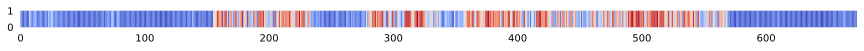

In [7]:
am = np.array(alphamissense("TTLL10"))
fig, ax = plt.subplots(1, 1, figsize=(15, 0.3))
ax.pcolor(np.expand_dims(am, axis=0), cmap='coolwarm') ;

## Positions polymorphic across baboons

In [8]:
baboons_all_polymorphic_zero_based = np.array([3, 15, 16, 28, 46, 57, 74, 107, 111, 125, 153, 159, 162, 
                            168, 202, 213, 244, 277, 278, 292, 344, 362, 363, 384, 399, 
                            430, 431, 434, 439, 460, 513, 519, 570, 574, 582, 596, 623, 
                            633, 636])
baboons_cross_species_polymorphic_zero_based = np.array([111, 162, 202, 277, 344, 363, 399, 430, 439])


def map_to_human_uniprot(baboon_zero_based):
    """
    │ Baboon X1, 0-based p │ Human (UniProt Q6ZVT0) │
    ├──────────────────────┼────────────────────────┤
    │ 0–38                 │ p + 1                  │
    ├──────────────────────┼────────────────────────┤
    │ 39–598               │ p + 28                 │
    ├──────────────────────┼────────────────────────┤
    │ 599–600 (PT)         │ no human counterpart   │
    ├──────────────────────┼────────────────────────┤
    │ ≥ 601                │ p + 26                 │
    """
    uniprot_one_based = []
    for p in baboon_zero_based.tolist():
        if p <= 38:
            uniprot_one_based.append(p+1)
        elif p <= 598:
            uniprot_one_based.append(p+28)
        elif p >= 601:
            uniprot_one_based.append(p+26)
        else:
            assert 0, 'no human counterpart'
    return np.array(uniprot_one_based)
    
baboons_all_polymorphic = map_to_human_uniprot(baboons_all_polymorphic_zero_based)
baboons_cross_species_polymorphic = map_to_human_uniprot(baboons_cross_species_polymorphic_zero_based)

' '.join([f'{p}' for p in baboons_all_polymorphic])

'4 16 17 29 74 85 102 135 139 153 181 187 190 196 230 241 272 305 306 320 372 390 391 412 427 458 459 462 467 488 541 547 598 602 610 624 649 659 662'

In [9]:
baboons_all_polymorphic

array([  4,  16,  17,  29,  74,  85, 102, 135, 139, 153, 181, 187, 190,
       196, 230, 241, 272, 305, 306, 320, 372, 390, 391, 412, 427, 458,
       459, 462, 467, 488, 541, 547, 598, 602, 610, 624, 649, 659, 662])

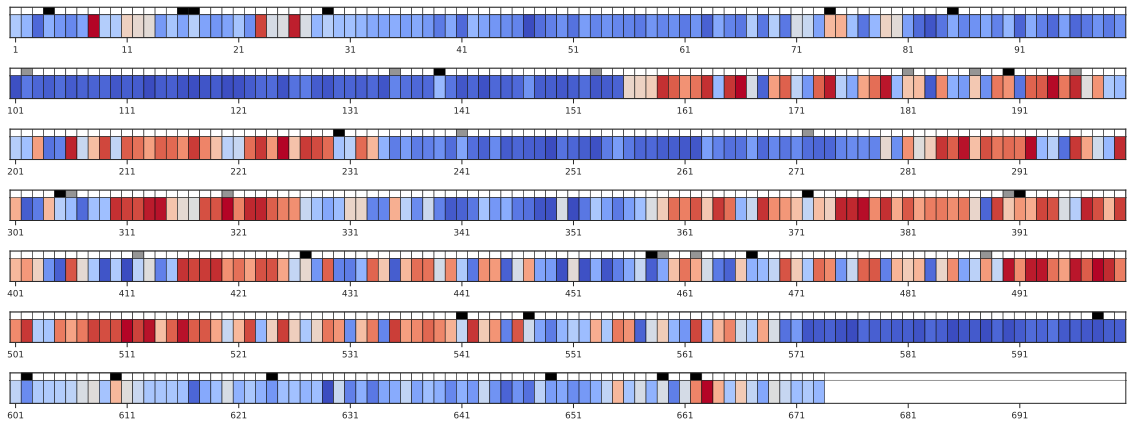

In [10]:
with sns.axes_style('ticks'):
    with sns.plotting_context('paper', font_scale=1):
        am = np.array(alphamissense("TTLL10"))
        is_baboon_poly = np.zeros(len(am))
        is_baboon_poly[baboons_all_polymorphic-1] = 0.5
        is_baboon_poly[baboons_cross_species_polymorphic-1] = 1
#        is_baboon_poly = np.array([int(x in baboons_all_polymorphic) for x in range(1, len(am)+1)])
        rows = 7
        per_row = len(am) / rows
        per_row = int(per_row // 10 * 10 + 10)

        fig = plt.figure(figsize=(20, 1.1*rows))        
        gs = GridSpec(rows*3, 1, figure=fig, hspace=0, height_ratios=[1, 3, 4]*rows)
        ax = None
        xticks = np.arange(0, per_row, 10)+0.5
        for i, r in enumerate(range(0, rows*3, 3)):
            ax = fig.add_subplot(gs[r, :])
            ax.pcolor(np.expand_dims(is_baboon_poly[(i*per_row):(i*per_row+per_row)], axis=0), cmap='Grays', edgecolors='k', linewidths=0.5)
            ax.get_yaxis().set_ticks([])
            ax.get_xaxis().set_ticks([])
            ax.yaxis.set_visible(False)
            ax.xaxis.set_visible(False)


            ax = fig.add_subplot(gs[r+1, :], sharex=ax)
            ax.pcolor(np.expand_dims(am[(i*per_row):(i*per_row+per_row)], axis=0), cmap='coolwarm', edgecolors='k', linewidths=0.5)
            ax.spines['top'].set_visible(False)
            ax.get_yaxis().set_ticks([])
            ax.yaxis.set_visible(False)

            ax = fig.add_subplot(gs[r+2, :], sharex=ax)
            ax.set_axis_off()
            ax.set_xticks(xticks)

            ax.set_xticklabels([int(x + i * per_row + 0.5) for x in xticks])
            ax.get_yaxis().set_ticks([])

            ax.set_xlim(0, per_row)
        plt.tight_layout()

In [11]:
human_nucl_polymorphic = seq[baboons_all_polymorphic-1].tolist()
'  '.join(human_nucl_polymorphic)

'G  W  R  G  A  R  V  P  P  P  G  Y  W  R  E  G  Q  G  L  R  H  L  R  A  T  L  V  T  P  L  A  A  E  A  E  R  R  A  L'

In [12]:
am = np.array(alphamissense("TTLL10", baboons_all_polymorphic))
fig, ax = plt.subplots(1, 1, figsize=(10, 0.3))
ax.pcolor(np.expand_dims(am, axis=0), edgecolors='k', linewidths=1, cmap='coolwarm') 
ax.set_axis_off()

In [13]:
show_structure("TTLL10", base="alphamissense",
            highlight=baboons_cross_species_polymorphic,
            highlight_color=None,
            highlight_radius=0.5,
            # sticks_for=baboons_all_polymorphic,
            controls=False,
            zoom=True,
            height=900,
            )

## All baboon polymorphic as fat sticks

In [14]:
show_structure("TTLL10", show='sticks', base="alphamissense",
            highlight=baboons_all_polymorphic,
            highlight_color=None,
            highlight_radius=0.5,
            sticks_for=baboons_all_polymorphic,
            zoom=True,
            controls=False,
            height=900,
            )

## Only cross-species polymorphic as fat sticks

In [15]:
show_structure("TTLL10", show='sticks', base="alphamissense",
            highlight=baboons_cross_species_polymorphic,
            highlight_color=None,
            highlight_radius=0.5,
            sticks_for=baboons_all_polymorphic,
            controls=False,
            zoom=True,
            height=900,
            )

## Only high-freq cross-species polymorphic as fat sticks

In [16]:
show_structure("TTLL10", #show='sticks',
                base="alphamissense",
            # highlight=[230, 305, 372, 391, 467],
            highlight=baboons_cross_species_polymorphic,
            highlight_color=None,
            highlight_radius=0.5,
            sticks_for=baboons_all_polymorphic,
            controls=False,
            zoom=True,
            height=900,
            )

`alphamissense()` returns the mean pathogenicity per residue (the values behind `base="alphamissense"`) as a list,
one per residue (element 0 = residue 1), or only for the residues given; human AlphaFold models only.

## Are cross-species polymorphisms are more pathogenic?

Pathogenic variants (score >0.75) are not significantly enriched among cross-species polymorphic (among all polymorphic):

In [21]:
am = alphamissense("TTLL10")
high_pat = set([i+1 for i, a in enumerate(alphamissense("TTLL10")) if a > 0.75])

fisher_test(baboons_cross_species_polymorphic, 
            high_pat, 
            list(range(1, len(am)+1)), 
            return_counts=True
            )

(0.6785417275173369, [[2, 160], [7, 504]])

Pathogenic variants (score >0.75) are not significantly enriched among cross-species polymorphic (among all protein positions):

In [22]:
fisher_test(baboons_cross_species_polymorphic, 
            high_pat.intersection(baboons_all_polymorphic), 
            baboons_all_polymorphic, 
            return_counts=True
            )

(0.424901681867626, [[2, 4], [7, 26]])

In [23]:
print('cross-species poly:')
for p in set(baboons_cross_species_polymorphic.tolist()).intersection(high_pat):
    print(f'Nr {p}: {am[p-1]:.2}')
print()
print('all other poly:')
for p in set(baboons_all_polymorphic.tolist()).difference(baboons_cross_species_polymorphic.tolist()).intersection(high_pat):
    print(f'Nr {p}: {am[p-1]:.2}')

cross-species poly:
Nr 190: 0.77
Nr 391: 0.79

all other poly:
Nr 320: 1.0
Nr 488: 0.79
Nr 196: 0.94
Nr 462: 0.75


In [25]:
with_sp_patho = alphamissense("TTLL10", set(baboons_all_polymorphic).difference(baboons_cross_species_polymorphic))
all_patho = alphamissense("TTLL10")
print(np.mean(with_sp_patho), "<", np.mean(all_patho))
      
result = scipy.stats.mannwhitneyu(
    alphamissense("TTLL10", set(baboons_all_polymorphic).difference(baboons_cross_species_polymorphic)),
    alphamissense("TTLL10"),
    alternative='less',
    )
print(f"p-value: {result.pvalue}")

0.36944052631578944 < 0.42719774771252056
p-value: 0.29847626694005425


In [ ]:
result = stats.mannwhitneyu(
    alphamissense("TTLL10", baboons_cross_species_polymorphic),
    alphamissense("TTLL10", baboons_all_polymorphic),
    alternative='greater',
    )
print(f"cross-species polymorphic vs. polymorphic: p-value: {result.pvalue}")

result = stats.mannwhitneyu(
    alphamissense("TTLL10", baboons_cross_species_polymorphic),
    alphamissense("TTLL10"),
    alternative='greater',
    )
print(f"cross-species polymorphic vs. all: p-value: {result.pvalue}")

cross-species polymorphic vs. polymorphic: p-value: 0.08270726353831176
cross-species polymorphic vs. all: p-value: 0.10331584315655112


## TODO

- Check if species with the LoF mutation accumulated more pathogenicity than those without it. Would suggest the protein was initially functional and that the additional mutations were allowed only after the protein became non-functinoal.
- Check if more pathogenic variants tend to be older (cross-species) than less pathogenic ones?: Pathogenic variants of the ancestral functional protein were initially under positive selection.

## Other proteins

The first argument can be a gene or protein name (looked up in UniProt for `organism`, human by default),
a UniProt accession, or a PDB ID. Names and accessions show the AlphaFold model; a PDB ID shows one chain
of the experimental structure (choose it with `chain=`; pLDDT colouring is not available there, and hovering
shows the B-factor instead). Everything is downloaded once and reused from `structures/`; the line under each
viewer says exactly which entry is shown.

```python
show_structure("TTLL10", organism="mouse", base="plddt")   # mouse Ttll10 (UniProt A4Q9F3)
show_structure("Q6ZVT0")                                    # by accession
show_structure("1UBQ", chain="A")                           # experimental structure from the PDB
```

In [50]:
show_structure("TTLL10", organism="mouse", base="plddt")   # mouse Ttll10 (UniProt A4Q9F3)
